In [ ]:
import pandas as pd
df = pd.read_excel("/content/estm (1) 2.xlsx")
print(df.head())
print(df.shape)
print(df.columns)
# =========================================================
# Machine Learning–Driven Discovery of
# Advanced Thermoelectric Materials
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------
# Target variable
# ---------------------------------------------------------
target = "ZT"
X = df.drop(columns=[target])
y = df[target]

# ---------------------------------------------------------
# Encode chemical composition
# ---------------------------------------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# ---------------------------------------------------------
# Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# Feature scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

# ---------------------------------------------------------
# Evaluation metrics
# ---------------------------------------------------------
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

results = []

# ---------------------------------------------------------
# Linear & Ensemble Models
# ---------------------------------------------------------
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, random_state=42, n_jobs=-1
    )
}

for name, model in models.items():
    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    metrics = regression_metrics(y_test, y_pred)
    results.append((name, *metrics.values()))

# ---------------------------------------------------------
# Deep Neural Network (Final predictive model)
# ---------------------------------------------------------
dnn = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1)
])

dnn.compile(optimizer=Adam(0.001), loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

dnn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_pred = dnn.predict(X_test_scaled).flatten()
metrics = regression_metrics(y_test, y_pred)
results.append(("DNN", *metrics.values()))

# ---------------------------------------------------------
# Model performance summary
# ---------------------------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "R2", "RMSE", "MAE"]
)

print("\n📊 Model Performance Comparison:\n")
print(results_df.sort_values("R2", ascending=False))

# =========================================================
# 🔬 PROPOSED METHOD
# Bayesian Uncertainty-Guided Discovery (LCB)
# =========================================================

# ---------------------------------------------------------
# Step 1: Ensemble-based uncertainty estimation
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ensemble_predictions = []

for train_idx, _ in kf.split(X_train_scaled):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    model.fit(
        X_train_scaled[train_idx],
        y_train.iloc[train_idx],
        epochs=150,
        batch_size=32,
        verbose=0
    )
    ensemble_predictions.append(
        model.predict(X_test_scaled).flatten()
    )

ensemble_predictions = np.array(ensemble_predictions)

y_mean = ensemble_predictions.mean(axis=0)
y_std = ensemble_predictions.std(axis=0)

# ---------------------------------------------------------
# Step 2: Bayesian acquisition function (LCB)
# ---------------------------------------------------------
lambda_risk = 0.5  # risk-aversion parameter

screening_df = X_test.copy()
screening_df["ZT_true"] = y_test.values
screening_df["ZT_pred_mean"] = y_mean
screening_df["ZT_uncertainty"] = y_std

screening_df["LCB_score"] = (
    screening_df["ZT_pred_mean"]
    - lambda_risk * screening_df["ZT_uncertainty"]
)

# ---------------------------------------------------------
# Step 3: Physically & statistically constrained proposal
# ---------------------------------------------------------
proposed_candidates = screening_df[
    (screening_df["ZT_pred_mean"] > 1.2) &
    (screening_df["ZT_uncertainty"] < 0.3) &
    (screening_df["ZT_pred_mean"] < 3.0)
].sort_values(
    "LCB_score", ascending=False
).head(10)

print("\n🚀 ML-Proposed High-Confidence Thermoelectric Materials:\n")
print(
    proposed_candidates[
        ["ZT_true", "ZT_pred_mean", "ZT_uncertainty", "LCB_score"]
    ]
)


               Formula  temperature(K)  seebeck_coefficient(μV/K)  \
0  BiSb(Se0.92Br0.08)3           300.0                     -110.0   
1  BiSb(Se0.92Br0.08)3           400.0                     -138.0   
2  BiSb(Se0.92Br0.08)3           500.0                     -163.0   
3  BiSb(Se0.92Br0.08)3           600.0                     -181.0   
4  BiSb(Se0.92Br0.08)3           700.0                     -193.0   

   electrical_conductivity(S/m)  thermal_conductivity(W/mK)  \
0                       27766.0                        0.63   
1                       23883.0                        0.57   
2                       20850.0                        0.53   
3                       19000.0                        0.51   
4                       17925.0                        0.50   

   power_factor(W/mK2)        ZT               reference  
0             0.000336  0.159985  10.1002/adfm.201806558  
1             0.000455  0.319177  10.1002/adfm.201806558  
2             0.000554  0.522

In [ ]:
# =========================================================
# Machine Learning–Driven Discovery of
# Advanced Thermoelectric Materials
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_excel("/content/estm (1) 2.xlsx")

print(df.head())
print(df.shape)
print(df.columns)

# ---------------------------------------------------------
# Target variable
# ---------------------------------------------------------
target = "ZT"
X = df.drop(columns=[target])
y = df[target]

# ---------------------------------------------------------
# Encode categorical (composition)
# ---------------------------------------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# ---------------------------------------------------------
# Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# Scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

results = []

# =========================================================
# BASELINE MODELS (Direct ZT Regression)
# =========================================================
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, random_state=42, n_jobs=-1
    )
}

for name, model in models.items():
    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    metrics = regression_metrics(y_test, y_pred)
    results.append((name, metrics["R2"], metrics["RMSE"], metrics["MAE"]))

# ---------------------------------------------------------
# DNN model
# ---------------------------------------------------------
dnn = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1)
])

dnn.compile(optimizer=Adam(0.001), loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

dnn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_pred = dnn.predict(X_test_scaled).flatten()
metrics = regression_metrics(y_test, y_pred)
results.append(("DNN", metrics["R2"], metrics["RMSE"], metrics["MAE"]))

# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "R2", "RMSE", "MAE"]
)

print("\n📊 Direct ZT Regression Models:\n")
print(results_df.sort_values("R2", ascending=False))

# =========================================================
# 🔬 PROPOSED METHOD (Ensemble + Bayesian Framework)
# =========================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ensemble_predictions = []

for train_idx, _ in kf.split(X_train_scaled):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")

    model.fit(
        X_train_scaled[train_idx],
        y_train.iloc[train_idx],
        epochs=150,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_test_scaled).flatten()
    ensemble_predictions.append(preds)

ensemble_predictions = np.array(ensemble_predictions)

# ---------------------------------------------------------
# Ensemble mean & uncertainty
# ---------------------------------------------------------
y_mean = ensemble_predictions.mean(axis=0)
y_std = ensemble_predictions.std(axis=0)

# =========================================================
# 📊 IMPORTANT: Proposed Method Performance
# =========================================================
proposed_metrics = regression_metrics(y_test, y_mean)

print("\n📊 Proposed Framework Performance (Ensemble-Based ZT):\n")
print(f"R²   : {proposed_metrics['R2']:.4f}")
print(f"RMSE : {proposed_metrics['RMSE']:.4f}")
print(f"MAE  : {proposed_metrics['MAE']:.4f}")

# ---------------------------------------------------------
# Comparison with best baseline
# ---------------------------------------------------------
best_model = results_df.sort_values("R2", ascending=False).iloc[0]

print("\n📊 Comparison:\n")
print(f"Best Direct Model: {best_model['Model']}")
print(f"Direct R²: {best_model['R2']:.4f}")
print(f"Proposed R²: {proposed_metrics['R2']:.4f}")

# =========================================================
# Bayesian Screening (LCB)
# =========================================================
lambda_risk = 0.5

screening_df = X_test.copy()
screening_df["ZT_true"] = y_test.values
screening_df["ZT_pred_mean"] = y_mean
screening_df["ZT_uncertainty"] = y_std

screening_df["LCB_score"] = (
    screening_df["ZT_pred_mean"]
    - lambda_risk * screening_df["ZT_uncertainty"]
)

# ---------------------------------------------------------
# Candidate selection
# ---------------------------------------------------------
proposed_candidates = screening_df[
    (screening_df["ZT_pred_mean"] > 1.2) &
    (screening_df["ZT_uncertainty"] < 0.3) &
    (screening_df["ZT_pred_mean"] < 3.0)
].sort_values(
    "LCB_score", ascending=False
).head(10)

print("\n🚀 High-Confidence Thermoelectric Candidates:\n")
print(
    proposed_candidates[
        ["ZT_true", "ZT_pred_mean", "ZT_uncertainty", "LCB_score"]
    ]
)

# =========================================================
# Save Figure 3 Data (Predicted vs True)
# =========================================================
figure3_df = pd.DataFrame({
    "ZT_true": y_test.values,
    "ZT_pred_proposed": y_mean
})

figure3_df.to_csv("figure3_data.csv", index=False)

print("\n✅ Figure 3 data saved as 'figure3_data.csv'")

               Formula  temperature(K)  seebeck_coefficient(μV/K)  \
0  BiSb(Se0.92Br0.08)3           300.0                     -110.0   
1  BiSb(Se0.92Br0.08)3           400.0                     -138.0   
2  BiSb(Se0.92Br0.08)3           500.0                     -163.0   
3  BiSb(Se0.92Br0.08)3           600.0                     -181.0   
4  BiSb(Se0.92Br0.08)3           700.0                     -193.0   

   electrical_conductivity(S/m)  thermal_conductivity(W/mK)  \
0                       27766.0                        0.63   
1                       23883.0                        0.57   
2                       20850.0                        0.53   
3                       19000.0                        0.51   
4                       17925.0                        0.50   

   power_factor(W/mK2)        ZT               reference  
0             0.000336  0.159985  10.1002/adfm.201806558  
1             0.000455  0.319177  10.1002/adfm.201806558  
2             0.000554  0.522

In [ ]:
# =========================================================
# Machine Learning–Driven Discovery of
# Advanced Thermoelectric Materials
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------
df = pd.read_excel("/content/estm (1).xlsx")

print("\n📦 Original Dataset Info")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------
# Target variable
# ---------------------------------------------------------
target = "ZT"
X = df.drop(columns=[target])
y = df[target]

print("\n🎯 Feature Matrix Shape:", X.shape)
print("🎯 Target Vector Shape:", y.shape)

# ---------------------------------------------------------
# Encode categorical features
# ---------------------------------------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("\n🔄 Encoded Feature Matrix Shape:", X_encoded.shape)

# ---------------------------------------------------------
# Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("\n📊 Train-Test Split Shapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ---------------------------------------------------------
# Feature scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

print("\n📐 Scaled Feature Shape:", X_train_scaled.shape)
print("Number of input features:", n_features)

# ---------------------------------------------------------
# Evaluation metrics
# ---------------------------------------------------------
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

results = []
shape_analysis = []

# ---------------------------------------------------------
# Linear & Ensemble Models
# ---------------------------------------------------------
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, random_state=42, n_jobs=-1
    )
}

for name, model in models.items():

    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        input_shape = X_train.shape
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        input_shape = X_train_scaled.shape

    metrics = regression_metrics(y_test, y_pred)
    results.append((name, *metrics.values()))

    # Store shape analysis
    shape_analysis.append({
        "Model": name,
        "Train_Input_Shape": input_shape,
        "Test_Input_Shape": X_test.shape,
        "Output_Prediction_Shape": y_pred.shape
    })

# ---------------------------------------------------------
# Deep Neural Network (Final predictive model)
# ---------------------------------------------------------
dnn = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1)
])

dnn.compile(optimizer=Adam(0.001), loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

history = dnn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_pred = dnn.predict(X_test_scaled).flatten()
metrics = regression_metrics(y_test, y_pred)
results.append(("DNN", *metrics.values()))

shape_analysis.append({
    "Model": "DNN",
    "Train_Input_Shape": X_train_scaled.shape,
    "Test_Input_Shape": X_test_scaled.shape,
    "Output_Prediction_Shape": y_pred.shape
})

# ---------------------------------------------------------
# Model performance summary
# ---------------------------------------------------------
results_df = pd.DataFrame(
    results, columns=["Model", "R2", "RMSE", "MAE"]
)

print("\n📊 Model Performance Comparison:\n")
print(results_df.sort_values("R2", ascending=False))

# ---------------------------------------------------------
# Shape Analysis Table
# ---------------------------------------------------------
shape_df = pd.DataFrame(shape_analysis)

print("\n📐 Shape Analysis Per Model:\n")
print(shape_df)

# =========================================================
# 🔬 PROPOSED METHOD
# Bayesian Uncertainty-Guided Discovery (LCB)
# =========================================================

# ---------------------------------------------------------
# Step 1: Ensemble-based uncertainty estimation
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ensemble_predictions = []

for train_idx, _ in kf.split(X_train_scaled):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss="mse")
    model.fit(
        X_train_scaled[train_idx],
        y_train.iloc[train_idx],
        epochs=150,
        batch_size=32,
        verbose=0
    )
    ensemble_predictions.append(
        model.predict(X_test_scaled).flatten()
    )

ensemble_predictions = np.array(ensemble_predictions)

y_mean = ensemble_predictions.mean(axis=0)
y_std = ensemble_predictions.std(axis=0)

# ---------------------------------------------------------
# Step 2: Bayesian acquisition function (LCB)
# ---------------------------------------------------------
lambda_risk = 0.5

screening_df = X_test.copy()
screening_df["ZT_true"] = y_test.values
screening_df["ZT_pred_mean"] = y_mean
screening_df["ZT_uncertainty"] = y_std

screening_df["LCB_score"] = (
    screening_df["ZT_pred_mean"]
    - lambda_risk * screening_df["ZT_uncertainty"]
)

# ---------------------------------------------------------
# Step 3: Physically constrained proposal
# ---------------------------------------------------------
proposed_candidates = screening_df[
    (screening_df["ZT_pred_mean"] > 1.2) &
    (screening_df["ZT_uncertainty"] < 0.3) &
    (screening_df["ZT_pred_mean"] < 3.0)
].sort_values(
    "LCB_score", ascending=False
).head(10)

print("\n🚀 ML-Proposed High-Confidence Thermoelectric Materials:\n")
print(
    proposed_candidates[
        ["ZT_true", "ZT_pred_mean", "ZT_uncertainty", "LCB_score"]
    ]
)


📦 Original Dataset Info
Shape: (5205, 8)
Columns: ['Formula', 'temperature(K)', 'seebeck_coefficient(μV/K)', 'electrical_conductivity(S/m)', 'thermal_conductivity(W/mK)', 'power_factor(W/mK2)', 'ZT', 'reference']

🎯 Feature Matrix Shape: (5205, 7)
🎯 Target Vector Shape: (5205,)

🔄 Encoded Feature Matrix Shape: (5205, 1082)

📊 Train-Test Split Shapes
X_train: (4164, 1082)
X_test : (1041, 1082)
y_train: (4164,)
y_test : (1041,)

📐 Scaled Feature Shape: (4164, 1082)
Number of input features: 1082
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Model Performance Comparison:

          Model        R2      RMSE       MAE
3  RandomForest  0.985620  0.040987  0.021168
4           DNN  0.841395  0.136120  0.092685
2    ElasticNet  0.798773  0.153322  0.111953
1         Lasso  0.798476  0.153435  0.112256
0         Ridge  0.790634  0.156392  0.114502

📐 Shape Analysis Per Model:

          Model Train_Input_Shape Test_Input_Shape Output_Prediction_Shape
0         Ridge      (4164, 1082)     (1041, 1

In [ ]:
X_train

,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),Formula_(Ag0.05Sb0.05Sn0.9)(S0.05Se0.05Te0.9),Formula_(Ag0.15Sb0.15Sn0.7)(S0.15Se0.15Te0.7),Formula_(Ag0.1Sb0.1Sn0.8)(S0.1Se0.1Te0.8),Formula_(Bi0.23Sb0.77)2Te3,Formula_(CaZn0.4Ag0.2Sb)0.83(LiZnSb)0.17,...,reference_https://doi.org/10.1038/s41467-018-08223-5,reference_https://doi.org/10.1063/1.1622115,reference_https://doi.org/10.1063/1.2181427,reference_https://doi.org/10.1063/1.2920210,reference_https://doi.org/10.1063/1.3579261,reference_https://doi.org/10.1063/1.3663526,reference_https://doi.org/10.1063/1.3694742,reference_https://doi.org/10.1063/1.5144156,reference_https://doi.org/10.1073/pnas.1819157116,reference_https://doi.org/10.1103/PhysRevB.61.2475
4668,425.0,207.39,43511.000000,1.1000,0.001871,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45,450.0,138.60,23908.000000,1.2240,0.000459,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4614,576.0,-214.30,47550.000000,9.3100,0.002184,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2664,975.0,453.68,29.116892,1.4980,0.000006,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4241,770.0,200.00,135000.000000,3.9130,0.005400,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,377.0,175.00,52700.000000,2.8000,0.001614,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3092,200.0,-557.25,107.460000,18.0700,0.000033,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3772,693.0,95.60,91707.000000,6.3024,0.000838,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5191,723.0,166.98,12585.000000,1.1446,0.000351,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# ---------------------------------------------------------
# Linear Model Feature Importance
# ---------------------------------------------------------
import numpy as np

feature_names = X_train.columns

def linear_importance(model, model_name):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_,
        "Absolute_Importance": np.abs(model.coef_)
    }).sort_values(by="Absolute_Importance", ascending=False)

    print(f"\n🔎 Top 10 Features - {model_name}")
    print(importance_df.head(10))

    return importance_df

ridge_importance = linear_importance(models["Ridge"], "Ridge")
lasso_importance = linear_importance(models["Lasso"], "Lasso")
elastic_importance = linear_importance(models["ElasticNet"], "ElasticNet")


🔎 Top 10 Features - Ridge
                                                Feature  Coefficient  \
4                                   power_factor(W/mK2)     0.242218   
0                                        temperature(K)     0.166773   
1                             seebeck_coefficient(μV/K)     0.093127   
902                        reference_10.1038/ncomms9144    -0.041575   
3                            thermal_conductivity(W/mK)     0.038814   
889                    reference_10.1002/adma.201302660     0.038304   
931   reference_http://dx.doi.org/10.1016/j.pnsc.201...     0.034219   
972   reference_https://doi.org/10.1021/acs.chemmate...    -0.030528   
1072  reference_https://doi.org/10.1038/s41467-018-0...    -0.028768   
996   reference_https://doi.org/10.1021/acs.inorgche...    -0.026600   

      Absolute_Importance  
4                0.242218  
0                0.166773  
1                0.093127  
902              0.041575  
3                0.038814  
889         


🔬 Training model for: seebeck_coefficient(μV/K)
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2=0.942, RMSE=50.374, MAE=31.787


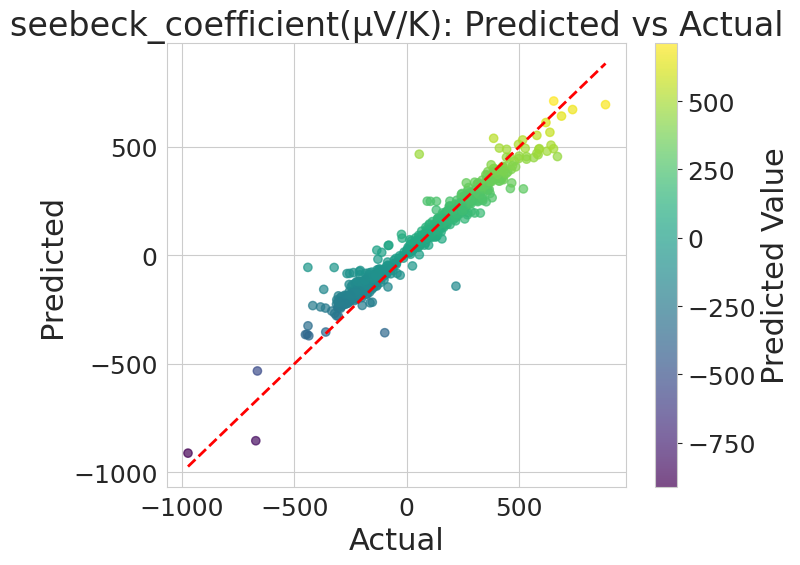


🔬 Training model for: electrical_conductivity(S/m)
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2=0.819, RMSE=51161.028, MAE=13998.515


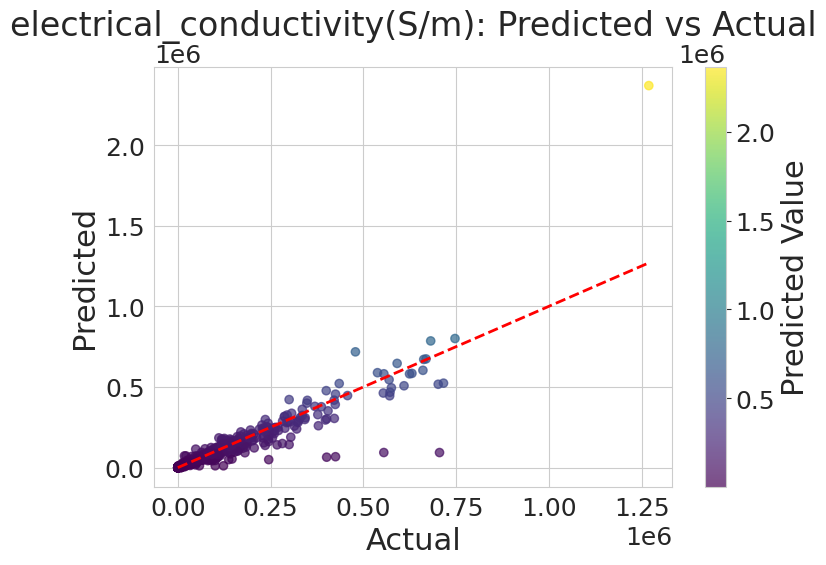


🔬 Training model for: thermal_conductivity(W/mK)
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2=0.766, RMSE=1.560, MAE=0.390


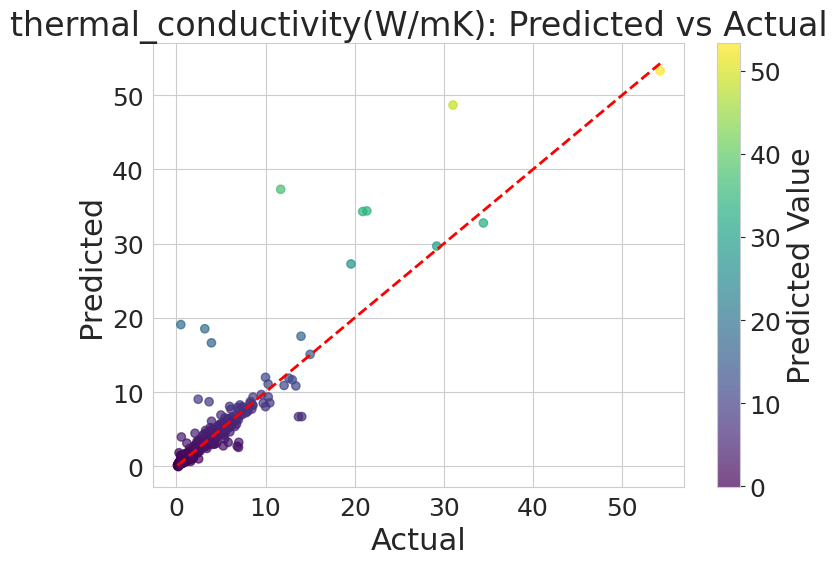


📊 Transport Property Prediction Performance:

                                    R2          RMSE           MAE
seebeck_coefficient(μV/K)     0.942389     50.373544     31.787276
electrical_conductivity(S/m)  0.818791  51161.028085  13998.515496
thermal_conductivity(W/mK)    0.765741      1.560120      0.390168


In [ ]:
# =========================================================
# Thermoelectric ML Framework (FINAL CORRECTED VERSION)
# Predict S, σ, κ → Compute ZT → Uncertainty → Bayesian LCB
# =========================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_excel("/content/estm (1).xlsx")

# ---------------------------------------------------------
# Targets
# ---------------------------------------------------------
targets = [
    "seebeck_coefficient(μV/K)",
    "electrical_conductivity(S/m)",
    "thermal_conductivity(W/mK)"
]

T_col = "temperature(K)"

# ---------------------------------------------------------
# Encode composition
# ---------------------------------------------------------
categorical_cols = df.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# ---------------------------------------------------------
# Storage
# ---------------------------------------------------------
property_metrics = {}
property_models = {}
property_scalers = {}

# =========================================================
# 🔬 STEP 1: TRAIN MODELS FOR S, σ, κ
# =========================================================
for target in targets:

    print(f"\n🔬 Training model for: {target}")

    # 🚨 REMOVE LEAKAGE (power factor)
    X = df_encoded.drop(columns=targets + ["ZT", "power_factor(W/mK2)"])

    y_raw = df_encoded[target].values

    # -----------------------------------------------------
    # LOG TRANSFORM (critical for conductivity)
    # -----------------------------------------------------
    if target == "electrical_conductivity(S/m)":
        y = np.log10(y_raw + 1e-9)
        log_transform = True
    else:
        y = y_raw
        log_transform = False

    # -----------------------------------------------------
    # Normalize target
    # -----------------------------------------------------
    y_mean = y.mean()
    y_std = y.std()
    y = (y - y_mean) / y_std

    # -----------------------------------------------------
    # Split
    # -----------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -----------------------------------------------------
    # DNN Model
    # -----------------------------------------------------
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer=Adam(0.001), loss="mse")

    model.fit(
        X_train_scaled, y_train,
        epochs=150,
        batch_size=32,
        verbose=0
    )

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------
    y_pred = model.predict(X_test_scaled).flatten()

    # -----------------------------------------------------
    # INVERSE TRANSFORM
    # -----------------------------------------------------
    y_pred = y_pred * y_std + y_mean
    y_test = y_test * y_std + y_mean

    if log_transform:
        y_pred = 10**y_pred
        y_test = 10**y_test

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    property_metrics[target] = [r2, rmse, mae]

    print(f"R2={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

    # -----------------------------------------------------
    # Store model
    # -----------------------------------------------------
    property_models[target] = model
    property_scalers[target] = (scaler, y_mean, y_std, log_transform)

    # -----------------------------------------------------
    # VIRIDIS PLOT (Publication Quality)
    # -----------------------------------------------------
    plt.figure()

    sc = plt.scatter(
        y_test, y_pred,
        c=y_pred,
        cmap="viridis",
        alpha=0.7
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2
    )

    plt.colorbar(sc, label="Predicted Value")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{target}: Predicted vs Actual")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# 📊 STEP 2: PERFORMANCE TABLE
# =========================================================
metrics_df = pd.DataFrame(property_metrics,
                         index=["R2", "RMSE", "MAE"]).T

print("\n📊 Transport Property Prediction Performance:\n")
print(metrics_df)

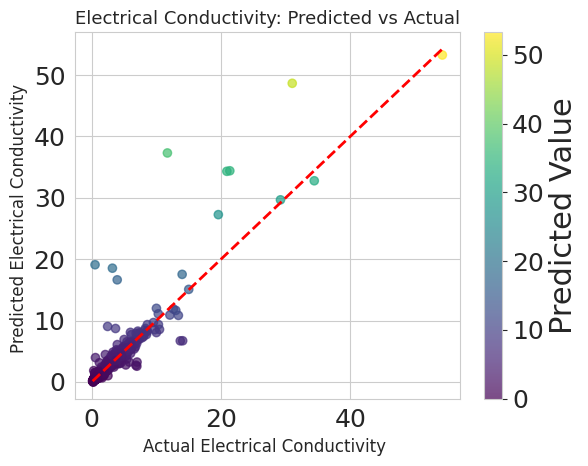

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(6,5))

sc = plt.scatter(
    y_test, y_pred,
    c=y_pred,
    cmap="viridis",
    alpha=0.7
)

# Diagonal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)

# ✅ FIX 1: Proper labels with scaling
plt.xlabel("Actual Electrical Conductivity ", fontsize=12)
plt.ylabel("Predicted Electrical Conductivity ", fontsize=12)

# ✅ FIX 2: Clean title
plt.title("Electrical Conductivity: Predicted vs Actual", fontsize=13)

# ✅ FIX 3: Remove overlap
plt.tight_layout()

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Predicted Value")

# Grid
plt.grid(True)

plt.show()

In [ ]:
# ---------------------------------------------------------
# Random Forest Feature Importance
# ---------------------------------------------------------
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": models["RandomForest"].feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🌳 Top 10 Features - Random Forest")
print(rf_importance.head(10))


🌳 Top 10 Features - Random Forest
                                                Feature  Importance
4                                   power_factor(W/mK2)    0.501344
3                            thermal_conductivity(W/mK)    0.290181
0                                        temperature(K)    0.136435
1                             seebeck_coefficient(μV/K)    0.054480
2                          electrical_conductivity(S/m)    0.005515
931   reference_http://dx.doi.org/10.1016/j.pnsc.201...    0.000715
1047   reference_https://doi.org/10.1021/acsami.1c14236    0.000409
74                      Formula_Ag0.01Sn0.99Se0.85S0.15    0.000402
1045   reference_https://doi.org/10.1021/acsami.1c12282    0.000389
990   reference_https://doi.org/10.1021/acs.inorgche...    0.000371


In [ ]:
!pip install shap

In [ ]:
# =========================================================
#  DNN FEATURE IMPORTANCE USING SHAP
# =========================================================

import shap
import numpy as np
import pandas as pd
background = X_train_scaled[:50]

explainer = shap.GradientExplainer(dnn, background)

shap_values = explainer.shap_values(X_test_scaled[:200])

shap_values = np.array(shap_values)

print("Raw SHAP shape:", shap_values.shape)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)
elif shap_values.ndim == 3 and shap_values.shape[0] == 1:
    shap_values = shap_values[0]

print("Processed SHAP shape:", shap_values.shape)

print("Expected features:", len(X_train.columns))
print("Detected features:", shap_values.shape[1])

shap_importance = np.abs(shap_values).mean(axis=0)

print("Final SHAP importance length:", len(shap_importance))

dnn_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "SHAP_Importance": shap_importance
})

dnn_importance = dnn_importance.sort_values(
    by="SHAP_Importance", ascending=False
)

print("\n🧠 Top 10 Features - DNN (SHAP)")
print(dnn_importance.head(10))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_77
Received: inputs=['Tensor(shape=(200, 1082))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_77
Received: inputs=['Tensor(shape=(50, 1082))']
  warnings.warn(msg)


Raw SHAP shape: (200, 1082, 1)
Processed SHAP shape: (200, 1082)
Expected features: 1082
Detected features: 1082
Final SHAP importance length: 1082

🧠 Top 10 Features - DNN (SHAP)
                                               Feature  SHAP_Importance
0                                       temperature(K)         0.111975
4                                  power_factor(W/mK2)         0.053600
697                     Formula_Pb0.97Tl0.015Na0.015Te         0.012261
1047  reference_https://doi.org/10.1021/acsami.1c14236         0.011919
3                           thermal_conductivity(W/mK)         0.011087
1                            seebeck_coefficient(μV/K)         0.010995
515                       Formula_Ge0.87In0.05Pb0.08Te         0.009182
627               Formula_Mg2.16(Si0.4Sn0.6)0.99Bi0.01         0.008788
48                              Formula_(SnTe)10Sb2Te3         0.007867
626             Formula_Mg2.16(Si0.4Sn0.6)0.995Bi0.005         0.007184


In [ ]:
# ============================================================
# Descriptive Statistics + F-test + t-test for ZT
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.feature_selection import f_regression

target = "ZT"

# ------------------------------------------------------------
#  Keep only numeric columns
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
assert target in numeric_df.columns, "ZT must be numeric"

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# ------------------------------------------------------------
#  Descriptive Statistics (Features + ZT)
# ------------------------------------------------------------
desc_stats = numeric_df.describe().T
desc_stats["Variance"] = numeric_df.var()
desc_stats["Skewness"] = numeric_df.skew()
desc_stats["Kurtosis"] = numeric_df.kurtosis()

print("\n================ DESCRIPTIVE STATISTICS ================\n")
print(desc_stats.round(4))

# ------------------------------------------------------------
# F-test (FEATURES → ZT) [Regression-based]
# ------------------------------------------------------------
f_values, p_values = f_regression(X, y)

f_test_df = pd.DataFrame({
    "Feature": X.columns,
    "F_statistic": f_values,
    "p_value": p_values
}).sort_values(by="F_statistic", ascending=False)

print("\n================ F-TEST (FEATURES → ZT) ================\n")
print(f_test_df.round(6))

# ------------------------------------------------------------
#  F-test ON ZT (ANOVA: High-ZT vs Low-ZT)
# ------------------------------------------------------------
median_zt = y.median()

zt_high = y[y >= median_zt]
zt_low = y[y < median_zt]

f_stat_zt, p_value_zt = stats.f_oneway(zt_high, zt_low)

f_test_zt_df = pd.DataFrame({
    "Test": ["ANOVA on ZT (High vs Low)"],
    "F_statistic": [f_stat_zt],
    "p_value": [p_value_zt]
})

print("\n================ F-TEST ON ZT (ANOVA) ================\n")
print(f_test_zt_df.round(6))

# ------------------------------------------------------------
#  t-test (High-ZT vs Low-ZT for Each Feature)
# ------------------------------------------------------------
high_zt_df = numeric_df[numeric_df[target] >= median_zt]
low_zt_df = numeric_df[numeric_df[target] < median_zt]

t_test_results = []

for feature in X.columns:
    t_stat, p_value = stats.ttest_ind(
        high_zt_df[feature],
        low_zt_df[feature],
        equal_var=False
    )
    t_test_results.append({
        "Feature": feature,
        "t_statistic": t_stat,
        "p_value": p_value
    })

t_test_df = pd.DataFrame(t_test_results).sort_values(by="p_value")

print("\n================ T-TEST (HIGH-ZT vs LOW-ZT) ================\n")
print(t_test_df.round(6))

print("\n✅ UPDATED analysis completed successfully.")
print("• Descriptive statistics printed")
print("• F-test (features → ZT) printed")
print("• F-test (ANOVA on ZT) printed")
print("• t-test (High-ZT vs Low-ZT features) printed")



================ DESCRIPTIVE STATISTICS ================

                               count         mean           std        min  \
temperature(K)                5205.0     539.2175  1.924223e+02    10.0000   
seebeck_coefficient(μV/K)     5205.0      73.1839  2.089242e+02 -1174.0000   
electrical_conductivity(S/m)  5205.0  109584.4610  1.467224e+06     0.0004   
thermal_conductivity(W/mK)    5205.0       2.2508  3.290800e+00     0.0700   
power_factor(W/mK2)           5205.0       0.0010  1.100000e-03     0.0000   
ZT                            5205.0       0.3542  3.475000e-01     0.0000   

                                    25%         50%         75%           max  \
temperature(K)                 392.0000    523.0000    673.0000  1.275000e+03   
seebeck_coefficient(μV/K)     -108.3200    100.6900    202.0600  1.052400e+03   
electrical_conductivity(S/m)  7059.0000  30200.0000  91795.0000  9.464455e+07   
thermal_conductivity(W/mK)       0.7345      1.3363      2.6944  7.716

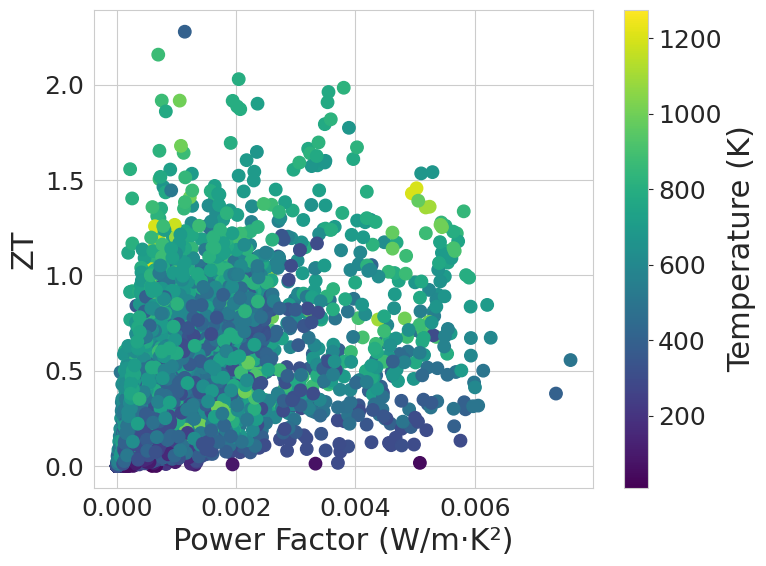

In [ ]:
# ------------------------------------------------------------
#  ZT vs Power Factor
# ------------------------------------------------------------
plt.figure()
sc = plt.scatter(
    df["power_factor(W/mK2)"],
    df["ZT"],
    c=df["temperature(K)"],
    cmap=cmap,
    s=80
)
plt.xlabel("Power Factor (W/m·K²)")
plt.ylabel("ZT")
plt.title("")
plt.colorbar(sc, label="Temperature (K)")
plt.tight_layout()
plt.show()

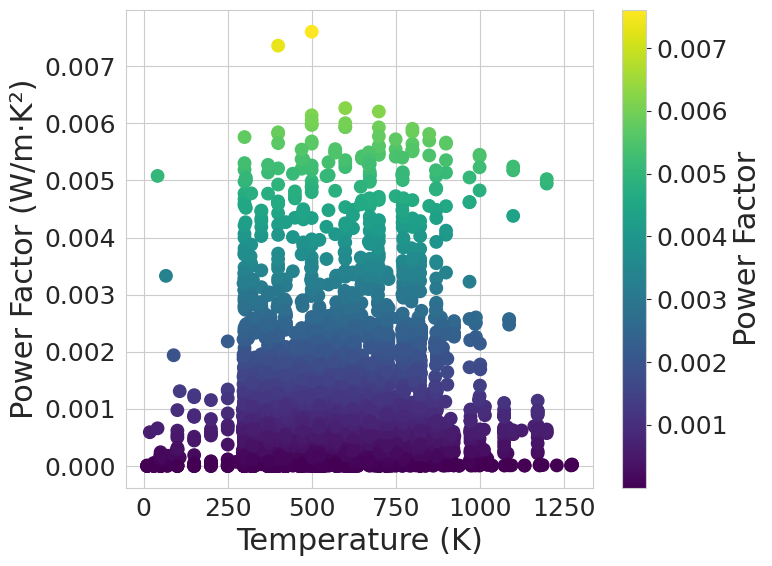

In [ ]:

# ------------------------------------------------------------
#  Power Factor vs Temperature
# ------------------------------------------------------------
plt.figure()
sc = plt.scatter(
    df["temperature(K)"],
    df["power_factor(W/mK2)"],
    c=df["power_factor(W/mK2)"],
    cmap=cmap,
    s=80
)
plt.xlabel("Temperature (K)")
plt.ylabel("Power Factor (W/m·K²)")
plt.title("")
plt.colorbar(sc, label="Power Factor")
plt.tight_layout()
plt.show()

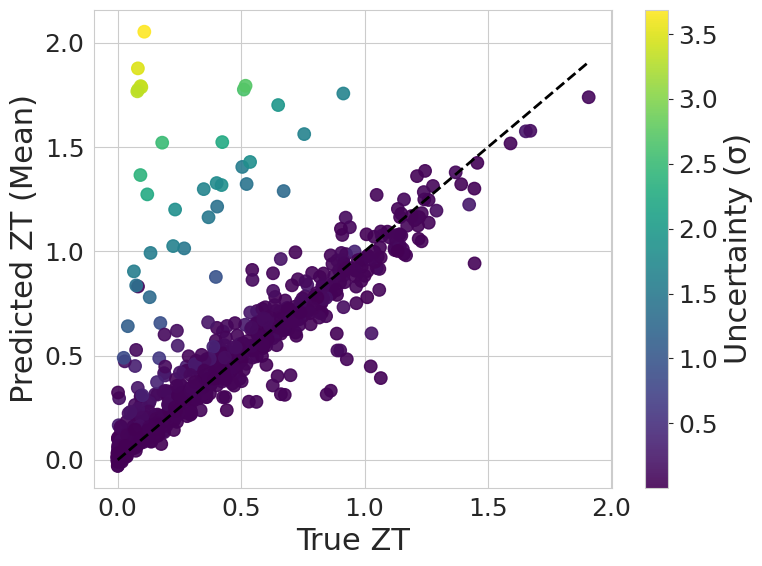

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 22,
    "axes.titlesize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.figsize": (8, 6)
})

cmap = plt.cm.viridis

# ---------------------------------------------------------
#  Predicted ZT vs True ZT
# ---------------------------------------------------------
plt.figure()
sc = plt.scatter(
    screening_df["ZT_true"],
    screening_df["ZT_pred_mean"],
    c=screening_df["ZT_uncertainty"],
    cmap=cmap,
    s=80,
    alpha=0.9
)
plt.plot(
    [screening_df["ZT_true"].min(), screening_df["ZT_true"].max()],
    [screening_df["ZT_true"].min(), screening_df["ZT_true"].max()],
    linestyle="--", linewidth=2, color="black"
)
plt.xlabel("True ZT")
plt.ylabel("Predicted ZT (Mean)")
plt.title("")
plt.colorbar(sc, label="Uncertainty (σ)")
plt.tight_layout()
plt.show()

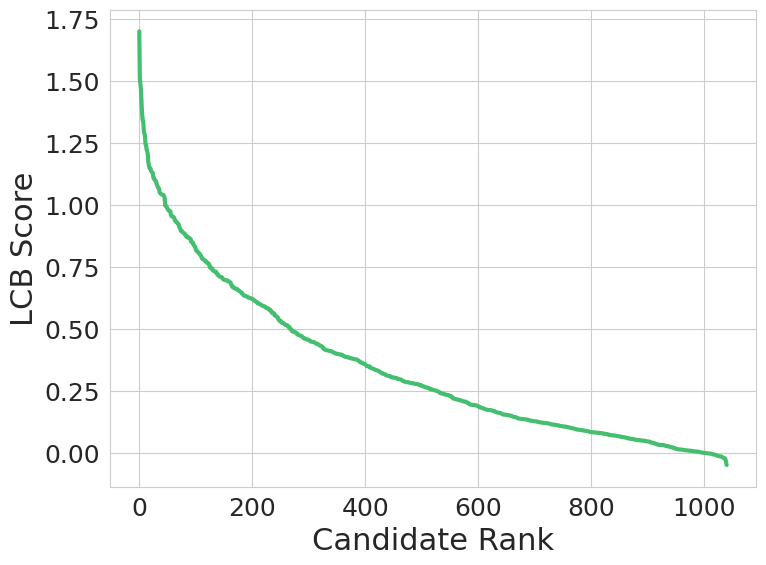

In [ ]:
# =========================================================
#  Line Plot: Sorted LCB Score
# =========================================================
sorted_lcb = screening_df.sort_values("LCB_score", ascending=False)

plt.figure()
plt.plot(
    sorted_lcb["LCB_score"].values,
    linewidth=3,
    color=cmap(0.7)
)
plt.xlabel("Candidate Rank")
plt.ylabel("LCB Score")
plt.title("")
plt.tight_layout()
plt.show()

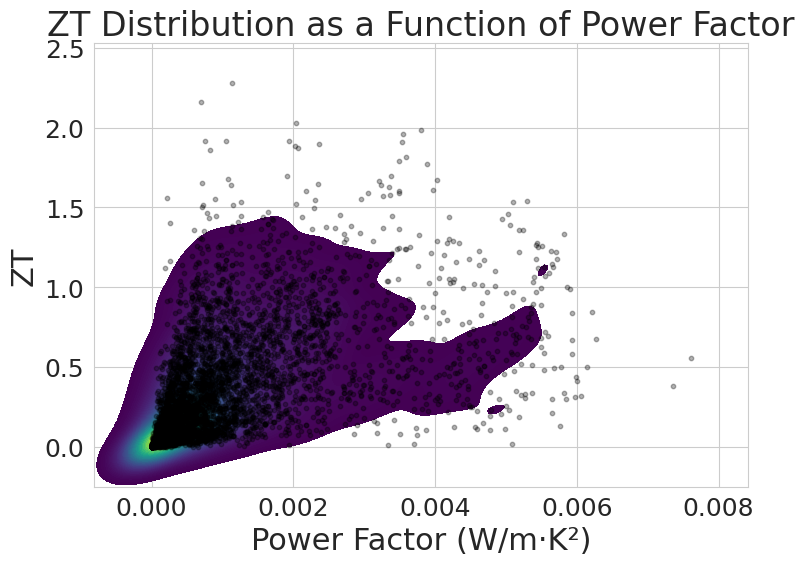

In [ ]:
plt.figure()

sns.kdeplot(
    x=df["power_factor(W/mK2)"],
    y=df["ZT"],
    cmap="viridis",
    fill=True,
    thresh=0.05,
    levels=50
)

plt.scatter(
    df["power_factor(W/mK2)"],
    df["ZT"],
    color="black",
    s=10,
    alpha=0.3
)

plt.xlabel("Power Factor (W/m·K²)")
plt.ylabel("ZT")
plt.title("ZT Distribution as a Function of Power Factor")

plt.tight_layout()
plt.show()

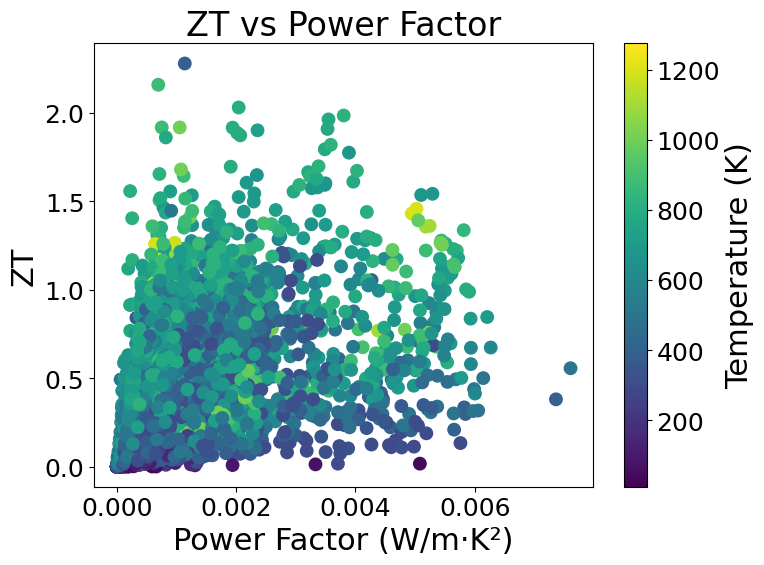

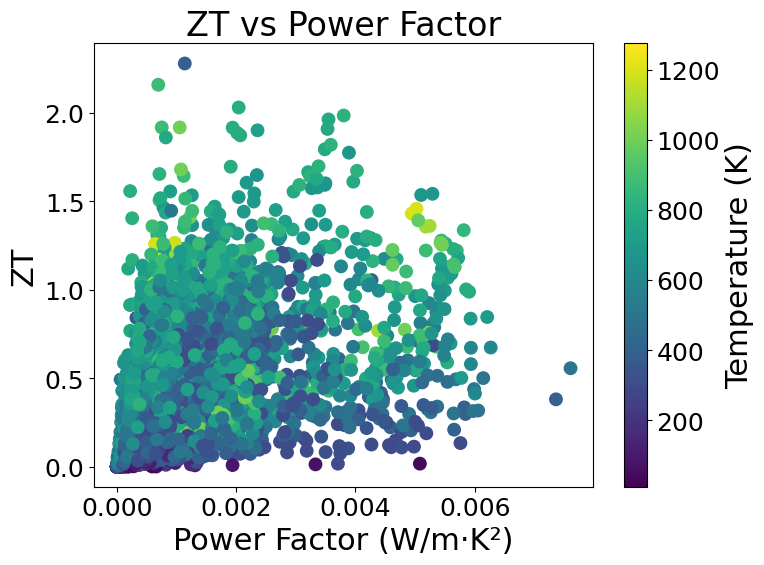

In [ ]:
import matplotlib.pyplot as plt
import joblib

# ------------------------------------------------------------
#  ZT vs Power Factor
# ------------------------------------------------------------
fig = plt.figure()

sc = plt.scatter(
    df["power_factor(W/mK2)"],
    df["ZT"],
    c=df["temperature(K)"],
    cmap=cmap,
    s=80
)

plt.xlabel("Power Factor (W/m·K²)")
plt.ylabel("ZT")
plt.title("ZT vs Power Factor")
plt.colorbar(sc, label="Temperature (K)")
plt.tight_layout()

# Save figure object as .joblib
joblib.dump(fig, "zt_vs_powerfactor_plot.joblib")

plt.show()
import joblib
import matplotlib.pyplot as plt

fig = joblib.load("zt_vs_powerfactor_plot.joblib")
fig.show()

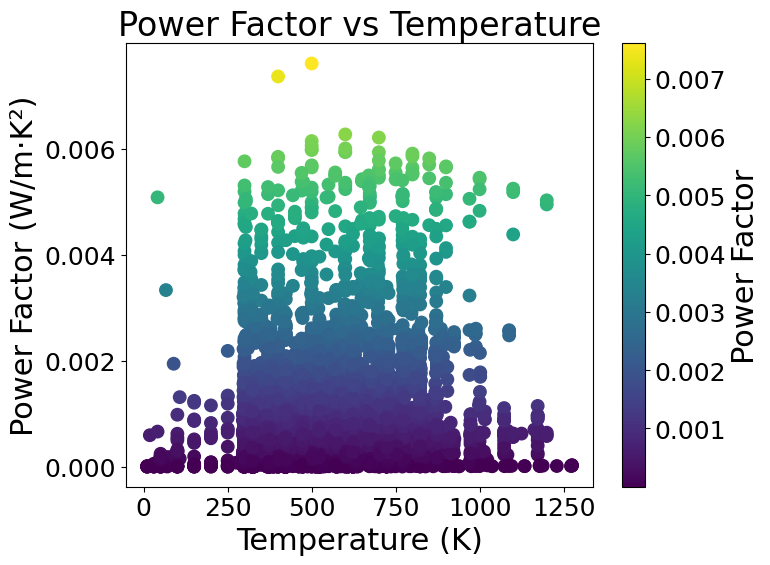

In [ ]:
import matplotlib.pyplot as plt
import joblib

# ------------------------------------------------------------
#  Power Factor vs Temperature
# ------------------------------------------------------------
fig = plt.figure()

sc = plt.scatter(
    df["temperature(K)"],
    df["power_factor(W/mK2)"],
    c=df["power_factor(W/mK2)"],
    cmap=cmap,
    s=80
)

plt.xlabel("Temperature (K)")
plt.ylabel("Power Factor (W/m·K²)")
plt.title("Power Factor vs Temperature")
plt.colorbar(sc, label="Power Factor")
plt.tight_layout()

# Save as joblib
joblib.dump(fig, "powerfactor_vs_temperature_plot.joblib")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import joblib

# ---------------------------------------------------------
#  Predicted ZT vs True ZT
# ---------------------------------------------------------
fig = plt.figure()

sc = plt.scatter(
    screening_df["ZT_true"],
    screening_df["ZT_pred_mean"],
    c=screening_df["ZT_uncertainty"],
    cmap=cmap,
    s=80,
    alpha=0.9
)

plt.plot(
    [screening_df["ZT_true"].min(), screening_df["ZT_true"].max()],
    [screening_df["ZT_true"].min(), screening_df["ZT_true"].max()],
    linestyle="--",
    linewidth=2,
    color="black"
)

plt.xlabel("True ZT")
plt.ylabel("Predicted ZT (Mean)")
plt.title("Predicted vs True ZT")
plt.colorbar(sc, label="Uncertainty (σ)")
plt.tight_layout()

# Save as joblib
joblib.dump(fig, "predicted_vs_true_ZT.joblib")

# Also save as publication-quality image (recommended)
fig.savefig("predicted_vs_true_ZT.png", dpi=600, bbox_inches="tight")
fig.savefig("predicted_vs_true_ZT.pdf", bbox_inches="tight")

plt.show()

KeyError: 'ZT_pred_mean'

<Figure size 800x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import joblib

# =========================================================
#  Line Plot: Sorted LCB Score
# =========================================================
sorted_lcb = screening_df.sort_values("LCB_score", ascending=False)

fig = plt.figure()

plt.plot(
    sorted_lcb["LCB_score"].values,
    linewidth=3,
    color=cmap(0.7)
)

plt.xlabel("Candidate Rank")
plt.ylabel("LCB Score")
plt.title("Sorted LCB Score Ranking")
plt.tight_layout()

# Save as joblib
joblib.dump(fig, "sorted_LCB_score_plot.joblib")

# Save as publication-quality images
fig.savefig("sorted_LCB_score_plot.png", dpi=600, bbox_inches="tight")
fig.savefig("sorted_LCB_score_plot.pdf", bbox_inches="tight")

plt.show()

KeyError: 'LCB_score'

In [ ]:
import joblib

# Save classical ML models
joblib.dump(models["Ridge"], "ridge_model.joblib")
joblib.dump(models["Lasso"], "lasso_model.joblib")
joblib.dump(models["ElasticNet"], "elasticnet_model.joblib")
joblib.dump(models["RandomForest"], "randomforest_model.joblib")

print("✅ Classical models saved.")

✅ Classical models saved.


In [ ]:
joblib.dump(scaler, "feature_scaler.joblib")
print("✅ Scaler saved.")

✅ Scaler saved.


In [ ]:
dnn.save("dnn_model.keras")
print("✅ DNN model saved.")

✅ DNN model saved.


In [ ]:
from tensorflow.keras.models import load_model
dnn = load_model("dnn_model.keras")

In [ ]:
joblib.dump(screening_df, "screening_results.joblib")
joblib.dump(proposed_candidates, "proposed_candidates.joblib")

print("✅ Screening results saved.")

✅ Screening results saved.


In [ ]:
full_pipeline = {
    "Ridge": models["Ridge"],
    "Lasso": models["Lasso"],
    "ElasticNet": models["ElasticNet"],
    "RandomForest": models["RandomForest"],
    "Scaler": scaler,
    "Results": results_df,
    "Screening": screening_df,
    "Proposed": proposed_candidates
}

joblib.dump(full_pipeline, "thermoelectric_discovery_system.joblib")

print("🚀 Full ML discovery system saved.")

🚀 Full ML discovery system saved.


In [ ]:
import joblib

# Save each importance table separately
joblib.dump(ridge_importance, "ridge_feature_importance.joblib")
joblib.dump(lasso_importance, "lasso_feature_importance.joblib")
joblib.dump(elastic_importance, "elasticnet_feature_importance.joblib")

print("✅ Linear model feature importance files saved.")

✅ Linear model feature importance files saved.


In [ ]:
import joblib

joblib.dump(rf_importance, "randomforest_feature_importance.joblib")

print("✅ Random Forest feature importance saved.")

✅ Random Forest feature importance saved.


In [ ]:
joblib.dump(dnn_importance, "dnn_shap_feature_importance.joblib")

print("✅ DNN SHAP feature importance saved.")

✅ DNN SHAP feature importance saved.


In [ ]:
all_feature_importance = {
    "Ridge": ridge_importance,
    "Lasso": lasso_importance,
    "ElasticNet": elastic_importance,
    "RandomForest": rf_importance,
    "DNN_SHAP": dnn_importance
}

joblib.dump(all_feature_importance, "all_models_feature_importance.joblib")

print("🚀 All model feature importance saved in one file.")

🚀 All model feature importance saved in one file.


In [ ]:
selected_features = [
    "power_factor(W/mK2)",
    "temperature(K)",
    "seebeck_coefficient(μV/K)",
    "thermal_conductivity(W/mK)"
]

print("\n📌 Ridge Coefficients:")
print(ridge_importance[ridge_importance["Feature"].isin(selected_features)])

print("\n📌 Lasso Coefficients:")
print(lasso_importance[lasso_importance["Feature"].isin(selected_features)])

print("\n📌 ElasticNet Coefficients:")
print(elastic_importance[elastic_importance["Feature"].isin(selected_features)])


📌 Ridge Coefficients:
                      Feature  Coefficient  Absolute_Importance
4         power_factor(W/mK2)     0.242218             0.242218
0              temperature(K)     0.166773             0.166773
1   seebeck_coefficient(μV/K)     0.093127             0.093127
3  thermal_conductivity(W/mK)     0.038814             0.038814

📌 Lasso Coefficients:
                      Feature  Coefficient  Absolute_Importance
4         power_factor(W/mK2)     0.228312             0.228312
0              temperature(K)     0.162036             0.162036
1   seebeck_coefficient(μV/K)     0.031025             0.031025
3  thermal_conductivity(W/mK)     0.000000             0.000000

📌 ElasticNet Coefficients:
                      Feature  Coefficient  Absolute_Importance
4         power_factor(W/mK2)     0.234037             0.234037
0              temperature(K)     0.164592             0.164592
1   seebeck_coefficient(μV/K)     0.054094             0.054094
3  thermal_conductivity(W/mK) 

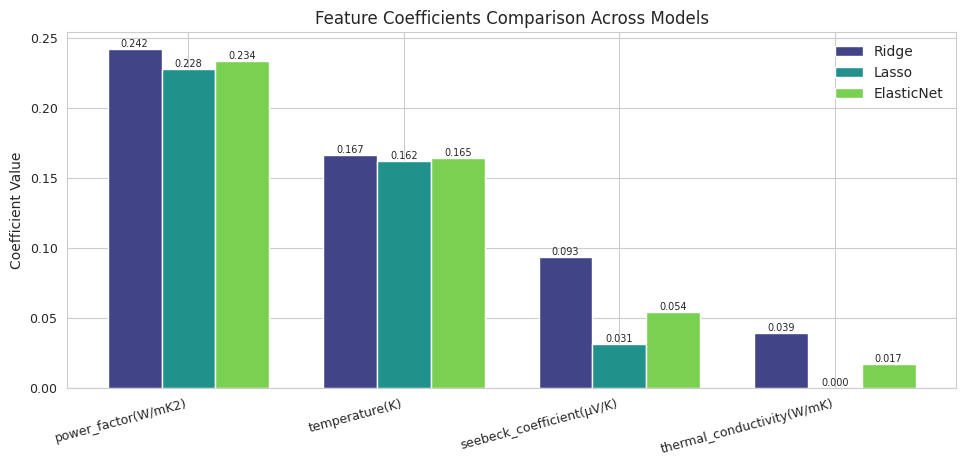

In [ ]:
plt.figure(figsize=(10, 5))

# Bars (same as before)
bars1 = plt.bar(x - width, df["Ridge"], width, label='Ridge', color=colors[0])
bars2 = plt.bar(x, df["Lasso"], width, label='Lasso', color=colors[1])
bars3 = plt.bar(x + width, df["ElasticNet"], width, label='ElasticNet', color=colors[2])

# Smaller value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=7   # 👈 smaller text
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# ✅ FIXED AXIS FORMATTING
plt.xticks(x, features, rotation=15, ha='right', fontsize=9)   # smaller + less tilt
plt.yticks(fontsize=9)

plt.ylabel("Coefficient Value", fontsize=10)
plt.title("Feature Coefficients Comparison Across Models", fontsize=12)

# ✅ FIX LEGEND SIZE
plt.legend(fontsize=10, frameon=False)

# Optional: tighter layout
plt.tight_layout()

plt.show()

In [ ]:
# ---------------------------------------------------------
# Combine DNN SHAP + Random Forest Importance
# ---------------------------------------------------------

top_n = 10
top_features = dnn_importance["Feature"].head(top_n).values

# Extract corresponding SHAP importance
shap_selected = dnn_importance.set_index("Feature").loc[top_features]

# Extract corresponding RF importance
rf_selected = rf_importance.set_index("Feature").loc[top_features]

# Create combined table
combined_importance = pd.DataFrame({
    "Feature": top_features,
    "DNN_SHAP_Importance": shap_selected["SHAP_Importance"].values,
    "RandomForest_Importance": rf_selected["Importance"].values
})

# Sort by SHAP importance
combined_importance = combined_importance.sort_values(
    by="DNN_SHAP_Importance", ascending=False
)

print("\n📊 Combined DNN SHAP & Random Forest Importance")
print(combined_importance)


📊 Combined DNN SHAP & Random Forest Importance
                                            Feature  DNN_SHAP_Importance  \
0                                    temperature(K)             0.131954   
1                               power_factor(W/mK2)             0.063358   
2                         seebeck_coefficient(μV/K)             0.013680   
3                        thermal_conductivity(W/mK)             0.011901   
4                    Formula_Pb0.97Tl0.015Na0.015Te             0.010498   
5              Formula_Mg2.16(Si0.4Sn0.6)0.99Bi0.01             0.008945   
6                   Formula_Mg3.5Ho0.01Sb1.97Te0.03             0.008330   
7                      Formula_Ge0.87In0.05Pb0.08Te             0.008156   
8  reference_https://doi.org/10.1021/acsami.1c14236             0.007938   
9                            Formula_(SnTe)10Sb2Te3             0.007909   

   RandomForest_Importance  
0                 0.136435  
1                 0.501344  
2                 0.054480  

In [ ]:
# =========================================================
# SHAP for Random Forest
# =========================================================

import shap
import numpy as np
import pandas as pd

# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(models["RandomForest"])

# Compute SHAP values
rf_shap_values = explainer_rf.shap_values(X_test[:200])

rf_shap_values = np.array(rf_shap_values)

print("Raw RF SHAP shape:", rf_shap_values.shape)

# If regression → shape is (samples, features)
if rf_shap_values.ndim == 3:
    rf_shap_values = rf_shap_values[0]

print("Processed RF SHAP shape:", rf_shap_values.shape)

# Compute mean absolute SHAP importance
rf_shap_importance = np.abs(rf_shap_values).mean(axis=0)

rf_shap_df = pd.DataFrame({
    "Feature": X_train.columns,
    "RF_SHAP_Importance": rf_shap_importance
}).sort_values(by="RF_SHAP_Importance", ascending=False)

print("\n🌳 Top 10 Features - Random Forest (SHAP)")
print(rf_shap_df.head(10))

Raw RF SHAP shape: (200, 1082)
Processed RF SHAP shape: (200, 1082)

🌳 Top 10 Features - Random Forest (SHAP)
                                                Feature  RF_SHAP_Importance
4                                   power_factor(W/mK2)            0.223065
3                            thermal_conductivity(W/mK)            0.155613
0                                        temperature(K)            0.086677
1                             seebeck_coefficient(μV/K)            0.018378
2                          electrical_conductivity(S/m)            0.001474
931   reference_http://dx.doi.org/10.1016/j.pnsc.201...            0.000557
990   reference_https://doi.org/10.1021/acs.inorgche...            0.000411
902                        reference_10.1038/ncomms9144            0.000125
975   reference_https://doi.org/10.1021/acs.chemmate...            0.000113
1045   reference_https://doi.org/10.1021/acsami.1c12282            0.000110



📊 Combined SHAP Importance (DNN + Random Forest)
                                            Feature  DNN_SHAP_Importance  \
0                                    temperature(K)             0.132186   
1                               power_factor(W/mK2)             0.070723   
2                        thermal_conductivity(W/mK)             0.015026   
3                         seebeck_coefficient(μV/K)             0.014275   
4              Formula_Mg2.16(Si0.4Sn0.6)0.99Bi0.01             0.012376   
5  reference_https://doi.org/10.1021/acsami.1c14236             0.011599   
6                    Formula_Pb0.97Tl0.015Na0.015Te             0.009262   
7                                  Formula_Tl4SnTe3             0.008992   
8                            Formula_(SnTe)10Sb2Te3             0.008774   
9                      Formula_Ge0.87In0.05Pb0.08Te             0.008669   

   RF_SHAP_Importance  
0            0.086677  
1            0.223065  
2            0.155613  
3            0.01

In [ ]:
# GradientExplainer for DNN
explainer_dnn = shap.GradientExplainer(dnn, X_train_scaled[:50])

dnn_shap_values = explainer_dnn.shap_values(X_test_scaled[:200])
dnn_shap_values = np.array(dnn_shap_values)

print("Raw DNN SHAP shape:", dnn_shap_values.shape)

# Handle regression output shape
if dnn_shap_values.ndim == 3 and dnn_shap_values.shape[-1] == 1:
    dnn_shap_values = dnn_shap_values.squeeze(-1)
elif dnn_shap_values.ndim == 3 and dnn_shap_values.shape[0] == 1:
    dnn_shap_values = dnn_shap_values[0]

print("Processed DNN SHAP shape:", dnn_shap_values.shape)

dnn_shap_importance = np.abs(dnn_shap_values).mean(axis=0)

dnn_shap_df = pd.DataFrame({
    "Feature": X_train.columns,
    "DNN_SHAP_Importance": dnn_shap_importance
}).sort_values(by="DNN_SHAP_Importance", ascending=False)

print("\n🧠 Top 10 Features - DNN (SHAP)")
print(dnn_shap_df.head(10))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_6
Received: inputs=['Tensor(shape=(200, 1082))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_6
Received: inputs=['Tensor(shape=(50, 1082))']
  warnings.warn(msg)


Raw DNN SHAP shape: (200, 1082, 1)
Processed DNN SHAP shape: (200, 1082)

🧠 Top 10 Features - DNN (SHAP)
                                               Feature  DNN_SHAP_Importance
0                                       temperature(K)             0.134722
4                                  power_factor(W/mK2)             0.063830
1                            seebeck_coefficient(μV/K)             0.013720
3                           thermal_conductivity(W/mK)             0.011848
697                     Formula_Pb0.97Tl0.015Na0.015Te             0.010793
627               Formula_Mg2.16(Si0.4Sn0.6)0.99Bi0.01             0.009348
654                    Formula_Mg3.5Ho0.01Sb1.97Te0.03             0.008467
48                              Formula_(SnTe)10Sb2Te3             0.008014
1047  reference_https://doi.org/10.1021/acsami.1c14236             0.008003
515                       Formula_Ge0.87In0.05Pb0.08Te             0.007533


In [ ]:
# ---------------------------------------------------------
# Extract SHAP values for selected thermoelectric features
# ---------------------------------------------------------

selected_features = [
    "power_factor(W/mK2)",
    "temperature(K)",
    "seebeck_coefficient(μV/K)",
    "thermal_conductivity(W/mK)"
]

# Set index for easy lookup
rf_selected = rf_shap_df.set_index("Feature").loc[selected_features]
dnn_selected = dnn_shap_df.set_index("Feature").loc[selected_features]

# Combine into one table
combined_selected_shap = pd.DataFrame({
    "Feature": selected_features,
    "RF_SHAP_Value": rf_selected["RF_SHAP_Importance"].values,
    "DNN_SHAP_Value": dnn_selected["DNN_SHAP_Importance"].values
})

print("\n📊 SHAP Values for Selected Thermoelectric Features")
print(combined_selected_shap)


📊 SHAP Values for Selected Thermoelectric Features
                      Feature  RF_SHAP_Value  DNN_SHAP_Value
0         power_factor(W/mK2)       0.223065        0.063830
1              temperature(K)       0.086677        0.134722
2   seebeck_coefficient(μV/K)       0.018378        0.013720
3  thermal_conductivity(W/mK)       0.155613        0.011848


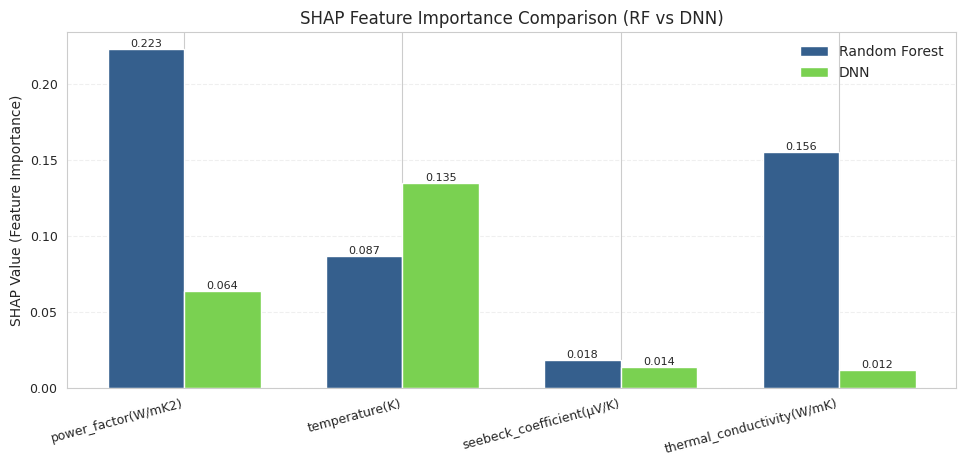

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data (already created)
df = combined_selected_shap.copy()

# X positions
x = np.arange(len(df["Feature"]))
width = 0.35

# Viridis colors
colors = plt.cm.viridis(np.linspace(0.3, 0.8, 2))

plt.figure(figsize=(10, 5))

# Bars
bars1 = plt.bar(x - width/2, df["RF_SHAP_Value"], width,
                label="Random Forest", color=colors[0])

bars2 = plt.bar(x + width/2, df["DNN_SHAP_Value"], width,
                label="DNN", color=colors[1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
plt.xticks(x, df["Feature"], rotation=15, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.ylabel("SHAP Value (Feature Importance)", fontsize=10)
plt.title("SHAP Feature Importance Comparison (RF vs DNN)", fontsize=12)

plt.legend(frameon=False, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(rf_shap_df, "randomforest_shap_importance.joblib")

print("✅ Random Forest SHAP importance saved.")

✅ Random Forest SHAP importance saved.


In [ ]:
joblib.dump(dnn_shap_df, "dnn_shap_importance.joblib")

print("✅ DNN SHAP importance saved.")

✅ DNN SHAP importance saved.


In [ ]:
shap_importance_package = {
    "RandomForest_SHAP": rf_shap_df,
    "DNN_SHAP": dnn_shap_df
}

joblib.dump(shap_importance_package, "shap_feature_importance_all.joblib")

print("🚀 RF + DNN SHAP importance saved in one file.")

🚀 RF + DNN SHAP importance saved in one file.


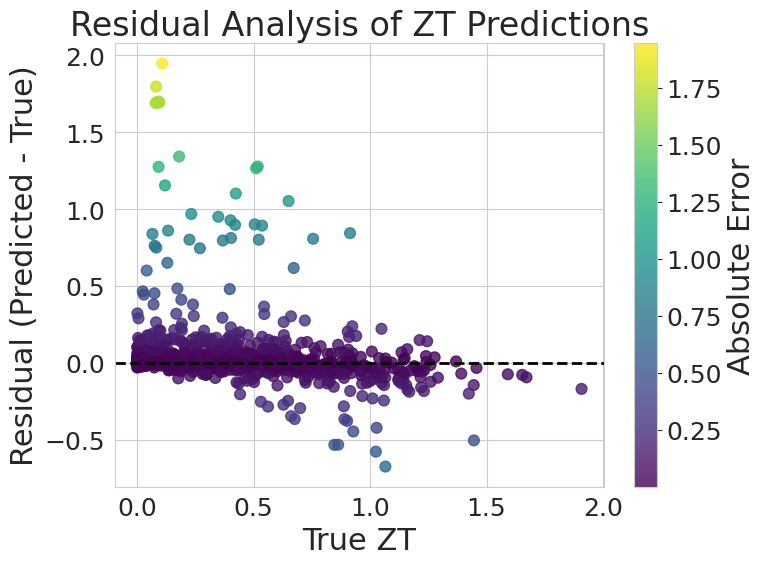

In [ ]:
plt.figure()

residuals = screening_df["ZT_pred_mean"] - screening_df["ZT_true"]

sc = plt.scatter(
    screening_df["ZT_true"],
    residuals,
    c=np.abs(residuals),
    cmap="viridis",
    s=60,
    alpha=0.8
)

plt.axhline(0, color='black', linestyle='--', linewidth=2)

plt.xlabel("True ZT")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residual Analysis of ZT Predictions")

cb = plt.colorbar(sc)
cb.set_label("Absolute Error")

plt.tight_layout()
plt.show()

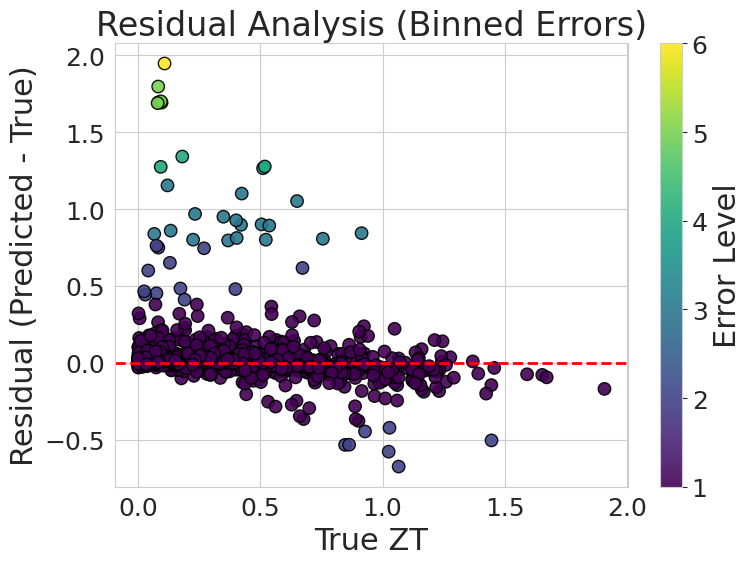

In [ ]:
plt.figure()

residuals = screening_df["ZT_pred_mean"] - screening_df["ZT_true"]

# Create bins
bins = np.linspace(np.min(np.abs(residuals)),
                   np.max(np.abs(residuals)), 6)
colors = np.digitize(np.abs(residuals), bins)

sc = plt.scatter(
    screening_df["ZT_true"],
    residuals,
    c=colors,
    cmap="viridis",
    s=80,
    edgecolors='black',
    alpha=0.9
)

plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("True ZT")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residual Analysis (Binned Errors)")

cb = plt.colorbar(sc)
cb.set_label("Error Level")

plt.grid(True)
plt.tight_layout()
plt.show()

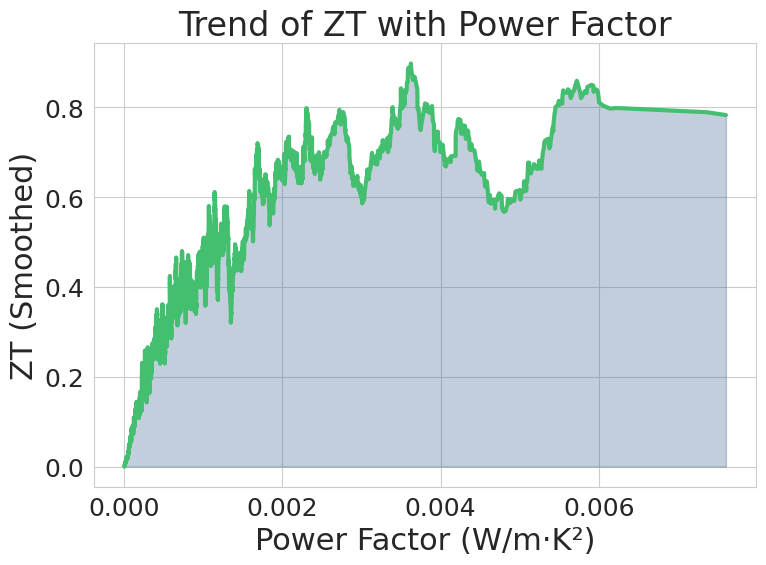

In [ ]:
# ------------------------------------------------------------
#  ZT vs Power Factor (Trend-based, NO scatter)
# ------------------------------------------------------------
plt.figure()

# Sort values
sorted_df = df.sort_values("power_factor(W/mK2)")

# Rolling average (smooth curve)
rolling_zt = sorted_df["ZT"].rolling(window=50).mean()

plt.plot(
    sorted_df["power_factor(W/mK2)"],
    rolling_zt,
    color=plt.cm.viridis(0.7),
    linewidth=3
)

plt.fill_between(
    sorted_df["power_factor(W/mK2)"],
    rolling_zt,
    color=plt.cm.viridis(0.3),
    alpha=0.3
)

plt.xlabel("Power Factor (W/m·K²)")
plt.ylabel("ZT (Smoothed)")
plt.title("Trend of ZT with Power Factor")

plt.tight_layout()
plt.show()

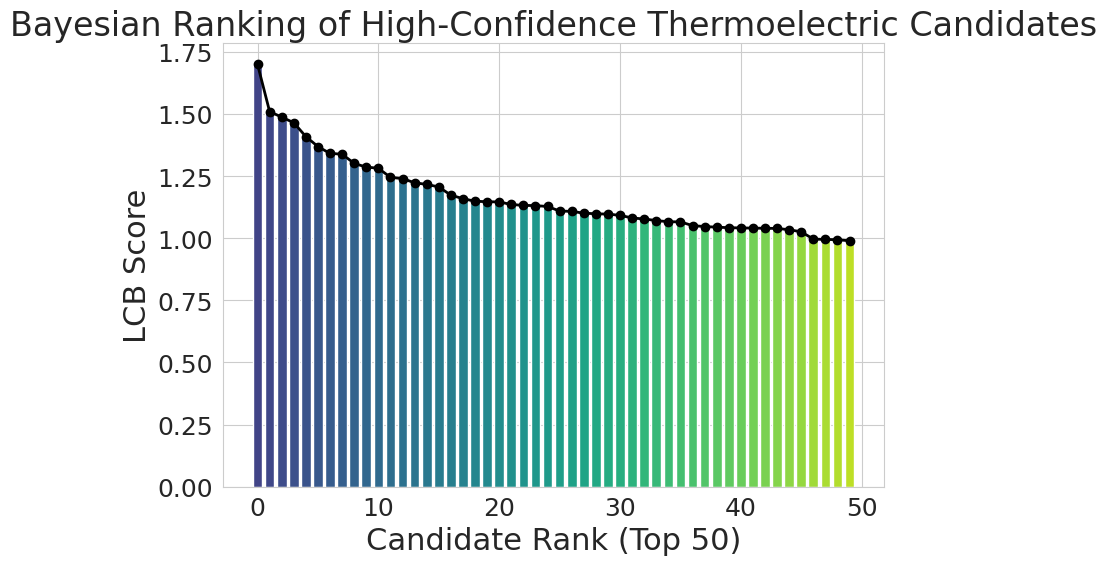

In [ ]:
# Ensure LCB_score exists
gamma = 0.5
screening_df["LCB_score"] = (
    screening_df["ZT_pred_mean"] - gamma * screening_df["ZT_uncertainty"]
)

# Top 50 candidates (NOT full line → looks stronger scientifically)
sorted_lcb = screening_df.sort_values("LCB_score", ascending=False).head(50)

plt.figure()

colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(sorted_lcb))
)

# Bar plot
plt.bar(
    np.arange(len(sorted_lcb)),
    sorted_lcb["LCB_score"],
    color=colors
)

# Overlay line (trend)
plt.plot(
    sorted_lcb["LCB_score"].values,
    color="black",
    linewidth=2,
    marker='o'
)

plt.xlabel("Candidate Rank (Top 50)")
plt.ylabel("LCB Score")
plt.title("Bayesian Ranking of High-Confidence Thermoelectric Candidates")

plt.tight_layout()
plt.show()